Relevante: Las gráficas finales son en 3D e intereactivas, por lo que para visualizarlas correctamente es necesario verlas desde colab. Para ello, ingresar al link https://colab.research.google.com/drive/1B6iDFS9zSB8eZEAqWJQ_00hxigkDzcUd?usp=sharing


# El conjunto de datos del pato rotatorio, aumentado a un toro $T^2$

La carpeta `ducks/` contiene **72 vistas en escala de grises de un pato rotando** en pasos de 5° (COIL-20, objeto 1). La rotación por sí sola ya es un círculo $S^1$.

Ahora vamos a añadir un "segundo círculo independiente" recoloreando cada fotograma con un colormap cíclico desplazado por una fase $\varphi \in [0, 1)$:

$$\text{color(píxel)} = \mathrm{cmap}\big((\text{intensidad} + \varphi)\ \mathrm{mod}\ 1\big).$$

Un mapa de colores cíclico satisface $\mathrm{cmap}(0) = \mathrm{cmap}(1)$ y es inyectivo en la rueda de colores, por lo que $\varphi \mapsto \text{imagen}$ es continua, periódica e inyectiva: dos fases dan la misma imagen solo si $\mathrm{cmap}(v+\varphi_1) = \mathrm{cmap}(v+\varphi_2)$ para cada intensidad del pato $v$, lo cual fuerza que $\varphi_1 = \varphi_2$. La fase de color es, por lo tanto, un $S^1$ genuino, independiente de la rotación. Los dos parámetros juntos dan

$$S^1_{\text{rotación}} \times S^1_{\text{color}} = T^2, \qquad b_0=1,\ b_1=2,\ b_2=1.$$

El fondo está enmascarado en negro, por lo que solo el pato lleva la fase de color; su rango de intensidades garantiza la inyectividad.


*   Elemento de lista
*   Elemento de lista



In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import os, glob, re
from PIL import Image
from scipy import ndimage
from matplotlib import colormaps

# Confirmación de que las librerías base se han cargado correctamente
print("ready")

ready


# Configuración de estilo para las figuras

In [ ]:
# -- Instalación de dependencias de sistema para renderizado LaTeX --
!sudo apt-get update -qq
!sudo apt-get install -qq texlive-latex-extra texlive-fonts-recommended dvipng cm-super

# -- Configuración global de estilo para Matplotlib --
# Establecemos un tamaño de fuente único para que todos los textos sean igualitarios
plt.rcParams.update({
    "text.usetex"        : True,
    "text.latex.preamble": r"\usepackage{amsmath} \usepackage{amssymb}",
    "font.family"        : "serif",
    "font.serif"         : ["Computer Modern Roman"],
    "font.size"           : 14,       # Tamaño base
    "axes.labelsize"      : 14,       # Igualamos etiquetas
    "axes.titlesize"      : 14,       # Igualamos títulos
    "xtick.labelsize"     : 14,       # Igualamos marcas X
    "ytick.labelsize"     : 14,       # Igualamos marcas Y
    "legend.fontsize"     : 14,       # Igualamos leyendas
    "figure.figsize"      : (7, 4.5),
    "axes.grid"           : True,
    "grid.alpha"          : 0.3,
})

print("Configuración cargada con tamaño de letra uniforme.")

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Configuración cargada con tamaño de letra uniforme.


## 1. Generamos el conjunto de datos

Cargamos los 72 fotogramas de origen y recoloreamos cada uno mediante un mapa de colores cíclico en `N_PHASE` fases equiespaciadas. Esto requiere la carpeta `ducks/` carpeta — conjunto `DATA_ROOT` a la ubicación donde se encuentre (un montaje de Drive, o sube un archivo zip cuando se pida).

In [ ]:
import os, glob, zipfile

# Configuración de rutas y archivos
DATA_ROOT = "."            # Directorio raíz de trabajo
ZIP_NAME  = "ducks.zip"    # Nombre del archivo comprimido esperado

def _find_frames(root):
    """Busca recursivamente archivos que sigan el patrón del dataset COIL-20 (obj1__*.png)."""
    return glob.glob(os.path.join(root, "**", "obj1__*.png"), recursive=True)

# 1) Verificación inicial: ¿Ya se han extraído las imágenes anteriormente?
hits = _find_frames(DATA_ROOT)

# 2) Búsqueda del archivo ZIP: Si no hay imágenes, buscamos el archivo ducks.zip en rutas comunes.
if not hits:
    zip_path = next(
        (p for p in (ZIP_NAME,
                     os.path.join(DATA_ROOT, ZIP_NAME),
                     os.path.join("/content", ZIP_NAME))
         if os.path.exists(p)),
        None,
    )

    # 3) Interacción con Colab: Si el archivo no existe localmente, solicitamos al usuario que lo suba.
    if zip_path is None:
        try:
            from google.colab import files as _colab_files
            print("Sube el archivo ducks.zip...")
            up = _colab_files.upload()
            # Buscamos el nombre del archivo recién subido
            zip_path = next((n for n in up if n.lower().endswith(".zip")), None)
        except Exception:
            pass

    if zip_path is None:
        raise FileNotFoundError(
            "No encontré ducks.zip. Súbelo al entorno y vuelve a ejecutar esta celda."
        )

    # 4) Extracción: Descomprimimos el contenido en la carpeta de trabajo.
    print("Descomprimiendo:", zip_path)
    with zipfile.ZipFile(zip_path) as zf:
        zf.extractall(DATA_ROOT)
    hits = _find_frames(DATA_ROOT)

# 5) Validación final: Identificamos la carpeta exacta de los fotogramas para su uso posterior.
if not hits:
    raise FileNotFoundError(
        "Descomprimí ducks.zip pero no hallé fotogramas obj1__*.png adentro."
    )

ducks_dir = os.path.dirname(sorted(hits)[0])
n_files   = len(glob.glob(os.path.join(ducks_dir, "obj1__*.png")))
print("Usando patos desde:", ducks_dir, "| fotogramas:", n_files)

Usando patos desde: ./ducks | fotogramas: 72


In [ ]:
# --- Parámetros de la Generación del Conjunto de Datos ---
CMAP_NAME = "twilight"   # Mapa de colores cíclico (comienza y termina en el mismo color)
N_PHASE   = 36           # Cantidad de variaciones de color por cada ángulo de rotación
FG_THRESH = 15           # Umbral para separar el pato (objeto) del fondo negro

def silhouette(gray):
    """Genera una máscara binaria del pato y rellena posibles huecos internos (como el ojo)."""
    return ndimage.binary_fill_holes(gray > FG_THRESH)

def recolor(gray, mask, phi, cmap):
    """Aplica un desplazamiento de fase 'phi' a las intensidades y mapea a un color RGB cíclico."""
    # Normalizamos la intensidad y sumamos la fase circular
    hue = (gray / 255.0 + phi) % 1.0
    # Convertimos a RGB usando el colormap
    rgb = (cmap(hue)[..., :3] * 255).astype(np.uint8)
    # Aplicamos la máscara para mantener el fondo negro puro
    rgb[~mask] = 0
    return rgb

# --- Procesamiento y Construcción del Dataset ---
cmap = colormaps[CMAP_NAME]
# Ordenamos los archivos por el ángulo de rotación extraído del nombre
files = sorted(glob.glob(os.path.join(ducks_dir, "obj1__*.png")),
               key=lambda f: int(re.search(r"__(\d+)", f).group(1)))
n_rot = len(files)

# Inicializamos contenedores para imágenes, índices de rotación e índices de color
images  = np.empty((n_rot * N_PHASE, 128, 128, 3), np.uint8)
rot_idx = np.empty(n_rot * N_PHASE, np.int16)
col_idx = np.empty(n_rot * N_PHASE, np.int16)

k = 0
for f in files:
    r = int(re.search(r"__(\d+)", f).group(1)) # Ángulo de rotación
    gray = np.array(Image.open(f).convert("L"))  # Carga en escala de grises
    mask = silhouette(gray)                     # Máscara del objeto
    for c in range(N_PHASE):                    # Generamos N_PHASE variaciones de color
        images[k] = recolor(gray, mask, c / N_PHASE, cmap)
        rot_idx[k] = r; col_idx[k] = c; k += 1

# Definimos los ángulos en radianes para representar el Toro T^2 (S1 x S1)
theta_rot = 2 * np.pi * rot_idx / n_rot
theta_col = 2 * np.pi * col_idx / N_PHASE
print("images:", images.shape, f"= {n_rot} rotations x {N_PHASE} color phases")

images: (2592, 128, 128, 3) = 72 rotations x 36 color phases


In [ ]:
import zipfile
from google.colab import files

# Nombre del archivo de salida
output_zip = "recolored_ducks.zip"

print("Comprimiendo imágenes... por favor espera.")

with zipfile.ZipFile(output_zip, 'w') as zf:
    for i in range(len(images)):
        # Convertimos el array de numpy a imagen PIL para guardarla
        img_pil = Image.fromarray(images[i])

        # Generamos un nombre descriptivo: rotacion_fase.png
        rot = rot_idx[i]
        phase = col_idx[i]
        filename = f"duck_rot{rot:03d}_phase{phase:02d}.png"

        # Guardamos temporalmente y añadimos al zip
        img_pil.save(filename)
        zf.write(filename)

        # Eliminamos el archivo temporal para no llenar el disco
        os.remove(filename)

print(f"¡Listo! Descargando {output_zip}...")
files.download(output_zip)

Comprimiendo imágenes... por favor espera.
¡Listo! Descargando recolored_ducks.zip...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 2. Una mirada a las muestras y la superficie latente

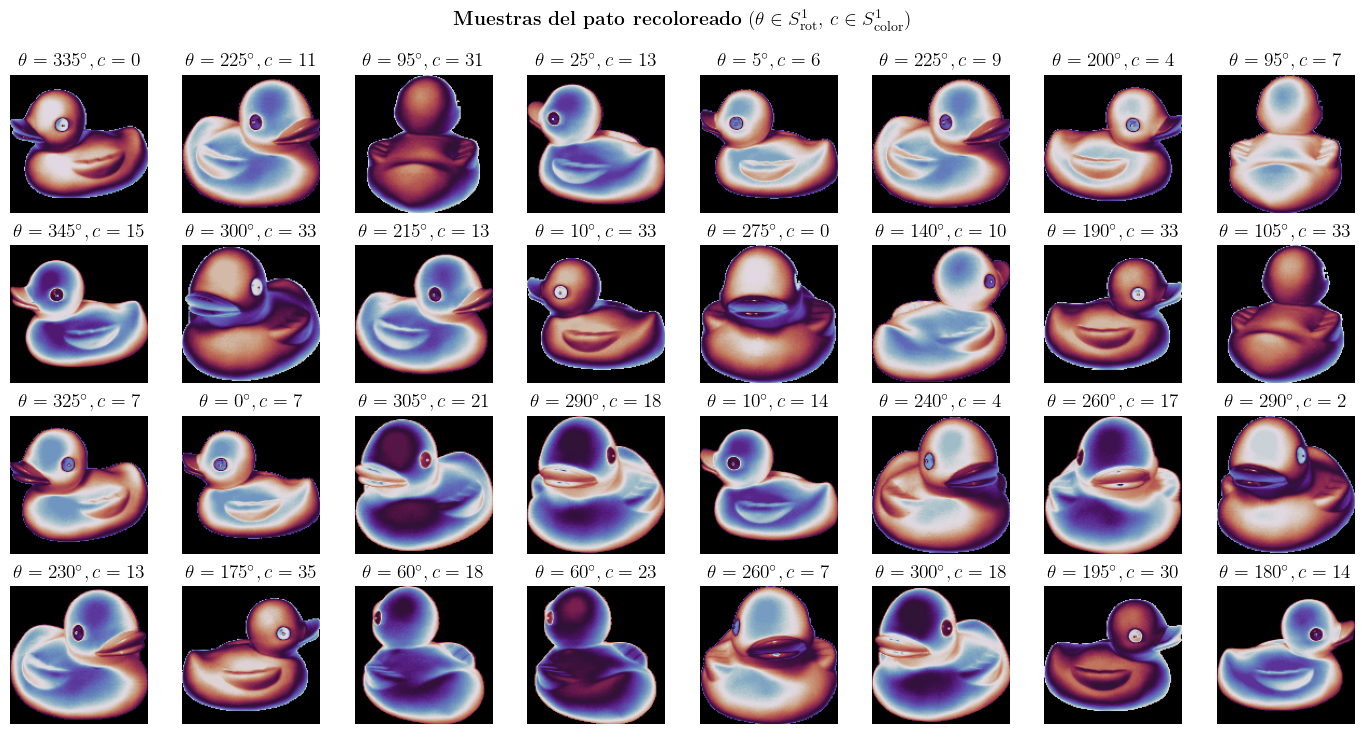

In [ ]:
# Visualización de una muestra aleatoria de imágenes generadas
sel = np.random.default_rng(0).choice(len(images), 32, replace=False)
fig, axes = plt.subplots(4, 8, figsize=(14, 7.5))

for ax, i in zip(axes.ravel(), sel):
    ax.imshow(images[i])
    ax.axis("off")
    rot_deg = int(rot_idx[i]) * 5
    col_k = int(col_idx[i])
    # Ajustamos el tamaño de fuente a 14 para que sea igualitario
    ax.set_title(rf"$\theta={rot_deg}^\circ, c={col_k}$", fontsize=14)

fig.suptitle(
    r"\textbf{Muestras del pato recoloreado} $(\theta \in S^1_{\text{rot}}, \, c \in S^1_{\text{color}})$",
    fontsize=14, y=0.98
)

fig.tight_layout()
plt.show()

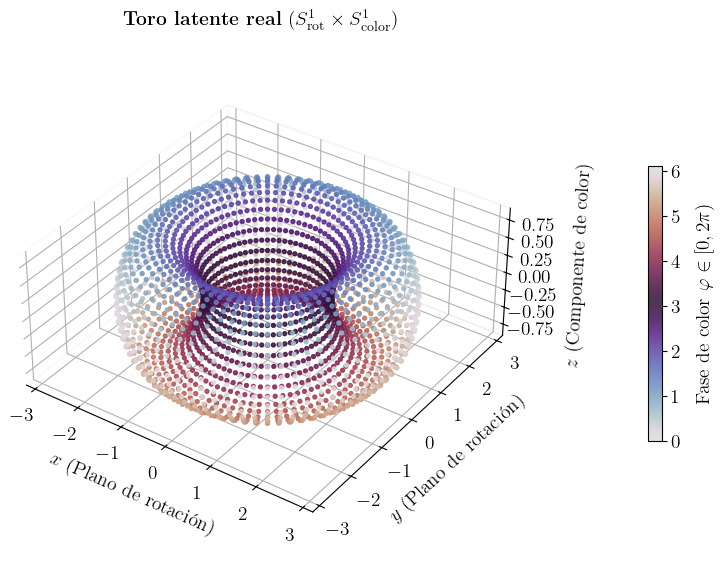

In [ ]:
# --- Mapeo a Coordenadas Cartesianas de un Toro en 3D ---
# R es el radio desde el centro del agujero al centro del tubo.
# r0 es el radio del tubo (la sección circular).
R, r0 = 2.0, 0.8

# Ecuaciones paramétricas del toro:
# x = (R + r cos(phi)) * cos(theta)
# y = (R + r cos(phi)) * sin(theta)
# z = r * sin(phi)
xt = (R + r0 * np.cos(theta_col)) * np.cos(theta_rot)
yt = (R + r0 * np.cos(theta_col)) * np.sin(theta_rot)
zt = r0 * np.sin(theta_col)

fig = plt.figure(figsize=(9.5, 6.5))
ax = fig.add_subplot(111, projection="3d")

# Graficamos cada muestra como un punto en el espacio 3D real de los parámetros
# Coloreamos los puntos según la fase de color para visualizar la continuidad
sc = ax.scatter(xt, yt, zt, c=theta_col, cmap="twilight", s=8, alpha=0.85)

# Estética y etiquetas científicas
ax.set_title(r"\textbf{Toro latente real} ($S^1_{\mathrm{rot}} \times S^1_{\mathrm{color}}$)", pad=20)
ax.set_xlabel(r"$x$ (Plano de rotación)", labelpad=8)
ax.set_ylabel(r"$y$ (Plano de rotación)", labelpad=8)
ax.set_zlabel(r"$z$ (Componente de color)", labelpad=8)

ax.set_box_aspect((1, 1, 0.45)) # Proporción de los ejes
ax.view_init(elev=35, azim=-55)  # Ángulo de cámara inicial

# Barra de colores lateral indicando la fase
cbar = fig.colorbar(sc, shrink=0.55, pad=0.18, fraction=0.03)
cbar.set_label(r"Fase de color $\varphi \in [0, 2\pi)$", labelpad=10)

# Desactivamos el fondo sólido de los planos para una apariencia más limpia
ax.xaxis.pane.fill = False
ax.yaxis.pane.fill = False
ax.zaxis.pane.fill = False

fig.subplots_adjust(left=0.05, right=0.85)
plt.show()

## 3. Autoencoder topológico

La red es un Autoencoder Convolucional Simétrico diseñado para comprimir imágenes RGB de $64 \times 64$ píxeles a un cuello de botella tridimensional ($z \in \mathbb{R}^3$) y posteriormente reconstruirlas. Como optimizador usamos ADAM, pero añadimos la **Loss topológica** de Moor, Horn, Rieck & Borgwardt, *Topological Autoencoders* (ICML 2020). La reconstrucción por sí sola permite que el cuello de botella de 3 unidades distorsione el toro; el término topológico impulsa al código latente a **preservar la topología del espacio de datos**.

Para un mini-batch, sean $A^X$ y $A^Z$ las matrices de distancias por pares en el espacio de datos (píxeles aplanados) y en el espacio latente (el código 3D). El artículo calcula la **homología persistente de dimensión 0** de cada uno, cuyos emparejamientos $\pi^X,\pi^Z$ son exactamente las aristas del **árbol de expansión mínima** de $A^X$ / $A^Z$ (Kruskal / union-find). Escribiendo $A[\pi]$ para el vector de distancias en esas aristas, el objetivo es

$$\mathcal{L} = \mathcal{L}_{\text{recon}} + \lambda\,\mathcal{L}_{\text{topo}},
\qquad
\mathcal{L}_{\text{topo}} = \mathcal{L}_{X\to Z} + \mathcal{L}_{Z\to X},$$

$$\mathcal{L}_{X\to Z} = \tfrac12\big\lVert A^X[\pi^X]-A^Z[\pi^X]\big\rVert^2,
\qquad
\mathcal{L}_{Z\to X} = \tfrac12\big\lVert A^Z[\pi^Z]-A^X[\pi^Z]\big\rVert^2$$

(Ecs. 1–3 del artículo). Los dos términos alinean las aristas topológicamente relevantes de cada espacio con las distancias correspondientes en el otro. Los emparejamientos se leen a partir de las matrices de distancias **desconectadas del grafo de cómputo** (*detached*) y se mantienen fijos; el artículo demuestra que la selección es estable ante perturbaciones infinitesimales, por lo que la pérdida es diferenciable y los gradientes fluyen únicamente a través de las distancias latentes $A^Z$. Seguimos la implementación oficial y normalizamos $A^X$ por el máximo del batch para que las distancias de los píxeles en alta dimensión no abrumen a las latentes; $\lambda$ es el único parámetro de ajuste. Configurar $\lambda=0$ recupera la loss de solo reconocimiento, la cual es error cuadratico medio.

## 3.1 Bloques compartidos: homología persistente, loss topológica y arquitectura

Haremos 2 entrenamientos, uno con $\lambda=0$ y otro con $\lambda=1$ esto con el fin de tener un entrenamiento de control y poder hacer comparativas mas adelantes.
Estos bloques se definen una sola vez y se reutilizan para entrenar el modelo de control ($\lambda=0$) y el modelo topológico ($\lambda=1$).

In [ ]:
class UnionFind:
    """Estructura de datos Disjoint-Set para gestionar componentes conectadas en Kruskal."""
    def __init__(self, m):
        self.parent = np.arange(m)

    def find(self, u):
        """Busca la raíz del conjunto al que pertenece u con compresión de camino."""
        while self.parent[u] != u:
            self.parent[u] = self.parent[self.parent[u]]
            u = self.parent[u]
        return u

    def merge(self, u, v):
        """Une los conjuntos de u y v."""
        self.parent[self.find(u)] = self.find(v)


def persistent_pairs(dist):
    """Calcula los pares de persistencia 0-dimensional encontrando el Árbol de Expansión Mínima (MST)."""
    m = dist.shape[0]
    iu, ju = np.triu_indices(m, k=1) # Índices de la mitad superior de la matriz de distancias
    order = np.argsort(dist[iu, ju], kind="stable") # Ordenamos aristas de menor a mayor
    uf = UnionFind(m)
    pairs = np.empty((m - 1, 2), dtype=np.int64)
    k = 0
    for e in order:
        u, v = iu[e], ju[e]
        if uf.find(u) != uf.find(v):
            uf.merge(u, v)
            pairs[k] = (u, v); k += 1 # Guardamos la arista si conecta componentes nuevas
            if k == m - 1: # Un MST de m nodos tiene m-1 aristas
                break
    return pairs


def pairwise(x, eps=1e-8):
    """Cálculo eficiente y diferenciable de la matriz de distancias Euclidianas (Batch x Batch)."""
    sq = (x * x).sum(1, keepdim=True)
    d2 = (sq - 2.0 * x @ x.t() + sq.t()).clamp_min(0.0)
    return torch.sqrt(d2 + eps) # eps evita el gradiente infinito en distancia cero


def topo_loss(Ax, Az):
    """Implementación de la Loss Topológica (Moor et al., 2020).
    Obliga a que las distancias de las aristas críticas en el espacio X se mantengan en el espacio Z,
    y viceversa (simetría)."""
    # Extraemos aristas críticas de X y Z de forma estática (sin gradientes)
    pi_x = persistent_pairs(Ax.detach().cpu().numpy())
    pi_z = persistent_pairs(Az.detach().cpu().numpy())
    ix, jx = pi_x[:, 0], pi_x[:, 1]
    iz, jz = pi_z[:, 0], pi_z[:, 1]

    # Calculamos la diferencia cuadrática solo sobre esas aristas críticas
    L_xz = 0.5 * ((Ax[ix, jx] - Az[ix, jx]) ** 2).sum()
    L_zx = 0.5 * ((Az[iz, jz] - Ax[iz, jz]) ** 2).sum()
    return L_xz + L_zx


class ConvAE(nn.Module):
    """Arquitectura del Autoencoder: Encoder reduce a 'z' dimensiones, Decoder reconstruye."""
    def __init__(self, z=3):
        super().__init__()
        # Reductores convolucionales: 64->32->16->8->4
        self.enc = nn.Sequential(
            nn.Conv2d(3, 16, 4, 2, 1), nn.BatchNorm2d(16), nn.ReLU(True),
            nn.Conv2d(16, 32, 4, 2, 1), nn.BatchNorm2d(32), nn.ReLU(True),
            nn.Conv2d(32, 64, 4, 2, 1), nn.BatchNorm2d(64), nn.ReLU(True),
            nn.Conv2d(64, 128, 4, 2, 1), nn.BatchNorm2d(128), nn.ReLU(True),
        )
        self.to_z = nn.Linear(128 * 4 * 4, z)   # Capa de cuello de botella
        self.from_z = nn.Linear(z, 128 * 4 * 4) # Re-expansión inicial
        # Reconstructores: 4->8->16->32->64
        self.dec = nn.Sequential(
            nn.ConvTranspose2d(128, 64, 4, 2, 1), nn.BatchNorm2d(64), nn.ReLU(True),
            nn.ConvTranspose2d(64, 32, 4, 2, 1), nn.BatchNorm2d(32), nn.ReLU(True),
            nn.ConvTranspose2d(32, 16, 4, 2, 1), nn.BatchNorm2d(16), nn.ReLU(True),
            nn.ConvTranspose2d(16, 3, 4, 2, 1), nn.Sigmoid(), # Sigmoid para rango [0,1]
        )

    def encode(self, x):
        return self.to_z(self.enc(x).flatten(1))

    def decode(self, z):
        return self.dec(self.from_z(z).view(-1, 128, 4, 4))

    def forward(self, x):
        z = self.encode(x)
        return self.decode(z), z

print("Bloques compartidos definidos.")

Bloques compartidos definidos.


In [ ]:
# --- Configuración del Entorno de Ejecución ---
device = "cuda" if torch.cuda.is_available() else "cpu"
if device == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("WARNING: running on CPU. In Colab enable the GPU via "
          "Runtime > Change runtime type > Hardware accelerator = GPU, then rerun.")
torch.backends.cudnn.benchmark = True # Optimiza el rendimiento de las capas convolucionales

# --- Preprocesamiento de Datos para PyTorch ---
# Reducimos resolución a la mitad (64x64) y normalizamos valores a [0, 1]
imgs64 = images[:, ::2, ::2, :].astype(np.float32) / 255.0
# Convertimos a Tensores de PyTorch y cambiamos dimensiones a (Batch, Canales, H, W)
X = torch.from_numpy(imgs64.transpose(0, 3, 1, 2)).contiguous()
Xg = X.to(device) # Cargamos todo el dataset en la memoria de la GPU (es pequeño)
n = len(Xg)

GPU: Tesla T4


## 3.2 Entrenamos el modelo de control ($\lambda=0$) y el modelo topológico ($\lambda=1$)

`train_model` encapsula el loop de entrenamiento y guarda el historial de ambas pérdidas por época, así podemos comparar convergencia además del resultado final.

In [ ]:
def train_model(lam, epochs=80, batch=128, seed=0, verbose_every=10):
    """Bucle de entrenamiento principal con soporte para pérdida topológica."""
    torch.manual_seed(seed)
    model = ConvAE(z=3).to(device)
    n_params = sum(p.numel() for p in model.parameters()) / 1e6
    print(f"[lambda={lam}] parámetros: {n_params:.2f}M")

    opt = torch.optim.Adam(model.parameters(), lr=1e-3)
    mse = nn.MSELoss() # Pérdida de reconstrucción estándar
    history = {"recon": [], "topo": []}

    for ep in range(1, epochs + 1):
        model.train()
        rec_tot = top_tot = 0.0
        perm = torch.randperm(n, device=device) # Mezclamos los datos en cada época

        for i in range(0, n, batch):
            xb = Xg[perm[i:i + batch]]
            recon, z = model(xb)

            Lr = mse(recon, xb) # Error cuadrático de los píxeles

            # Cálculo de distancias y Loss Topológica
            Ax = pairwise(xb.flatten(1)); Ax = Ax / Ax.max() # Normalización espacial
            Az = pairwise(z)
            Lt = topo_loss(Ax, Az)

            # Loss total: si lam=0, Lt no afecta los gradientes (modelo de control)
            loss = Lr + lam * Lt

            opt.zero_grad(); loss.backward(); opt.step()

            rec_tot += Lr.item() * len(xb)
            top_tot += Lt.item() * len(xb)

        # Almacenamos promedios por época
        history["recon"].append(rec_tot / n)
        history["topo"].append(top_tot / n)

        if ep == 1 or ep % verbose_every == 0:
            recon_last, topo_last = history["recon"][-1], history["topo"][-1]
            print(f"  epoch {ep:3d}  recon {recon_last:.4f}   topo {topo_last:.4f}")

    return model, history


def encode_all(model, batch=512):
    """Función de utilidad para extraer todas las representaciones latentes 3D."""
    model.eval()
    Z = np.empty((n, 3), np.float32)
    with torch.no_grad():
        for i in range(0, n, batch):
            Z[i:i + batch] = model.encode(Xg[i:i + batch]).cpu().numpy()
    return Z

In [ ]:
# Parámetros globales de entrenamiento
EPOCHS, BATCH = 80, 128

# --- Entrenamiento del Modelo 0: Sin restricción topológica ---
print("=== Modelo de control (sin loss topológica, lambda=0) ===")
model0, hist0 = train_model(lam=0.0, epochs=EPOCHS, batch=BATCH, seed=0)

# --- Entrenamiento del Modelo 1: Con restricción topológica activa ---
print("\n=== Modelo topológico (lambda=1) ===")
model1, hist1 = train_model(lam=1.0, epochs=EPOCHS, batch=BATCH, seed=0)

# Codificación final de los datos en ambos modelos para comparación visual
Z0 = encode_all(model0)
Z1 = encode_all(model1)

=== Modelo de control (sin loss topológica, lambda=0) ===
[lambda=0.0] parámetros: 0.36M
  epoch   1  recon 0.1236   topo 127.0188
  epoch  10  recon 0.0235   topo 503.9224
  epoch  20  recon 0.0156   topo 547.4075
  epoch  30  recon 0.0130   topo 557.5381
  epoch  40  recon 0.0114   topo 598.6557
  epoch  50  recon 0.0108   topo 674.8177
  epoch  60  recon 0.0101   topo 607.9794
  epoch  70  recon 0.0094   topo 673.5410
  epoch  80  recon 0.0089   topo 549.9321

=== Modelo topológico (lambda=1) ===
[lambda=1.0] parámetros: 0.36M
  epoch   1  recon 0.1228   topo 10.9937
  epoch  10  recon 0.0319   topo 1.4552
  epoch  20  recon 0.0259   topo 1.1062
  epoch  30  recon 0.0246   topo 1.0876
  epoch  40  recon 0.0222   topo 1.0903
  epoch  50  recon 0.0265   topo 1.2127
  epoch  60  recon 0.0201   topo 1.1185
  epoch  70  recon 0.0281   topo 1.3500
  epoch  80  recon 0.0249   topo 1.1028


## 3.3 Curvas de entrenamiento: control vs. modelo topológico

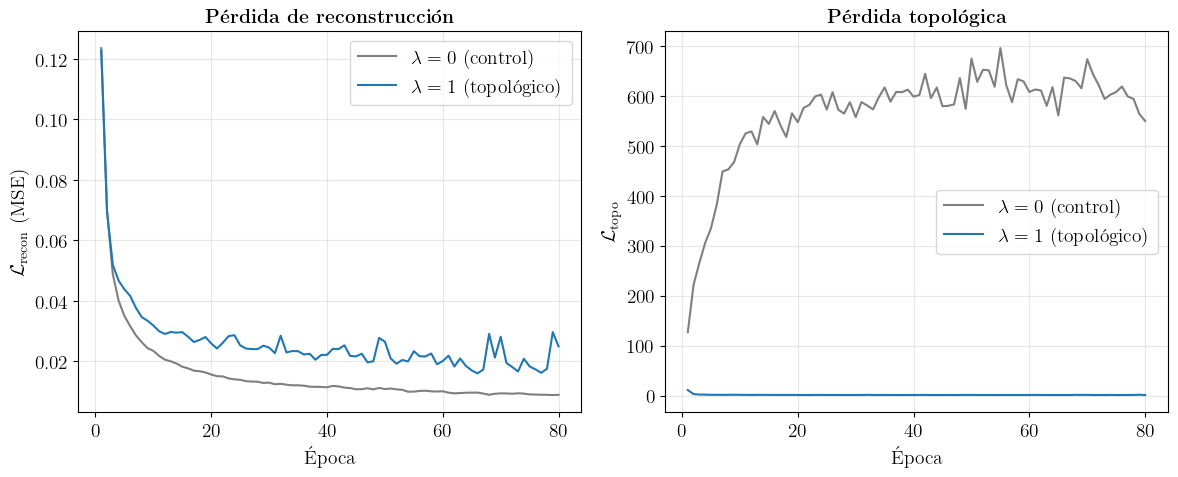

In [ ]:
# Generación de gráficas de convergencia
epochs_axis = np.arange(1, EPOCHS + 1)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Gráfico Izquierdo: Reconstrucción
axes[0].plot(epochs_axis, hist0["recon"], label=r"$\lambda=0$ (control)", color="tab:gray")
axes[0].plot(epochs_axis, hist1["recon"], label=r"$\lambda=1$ (topológico)", color="tab:blue")
axes[0].set_title(r"\textbf{Pérdida de reconstrucción}", fontsize=14)
axes[0].set_xlabel("Época", fontsize=14)
axes[0].set_ylabel(r"$\mathcal{L}_{\text{recon}}$ (MSE)", fontsize=14)
axes[0].legend(fontsize=14)

# Gráfico Derecho: Topológica
axes[1].plot(epochs_axis, hist0["topo"], label=r"$\lambda=0$ (control)", color="tab:gray")
axes[1].plot(epochs_axis, hist1["topo"], label=r"$\lambda=1$ (topológico)", color="tab:blue")
axes[1].set_title(r"\textbf{Pérdida topológica}", fontsize=14)
axes[1].set_xlabel("Época", fontsize=14)
axes[1].set_ylabel(r"$\mathcal{L}_{\text{topo}}$", fontsize=14)
axes[1].legend(fontsize=14)

fig.tight_layout()
plt.show()

## 3.4 Comparación de reconstrucciones

`plot_reconstructions` recibe un diccionario `{etiqueta: modelo}` y dibuja la entrada junto con la reconstrucción de cada modelo para las mismas imágenes, evitando repetir el bloque de ploteo para cada $\lambda$.

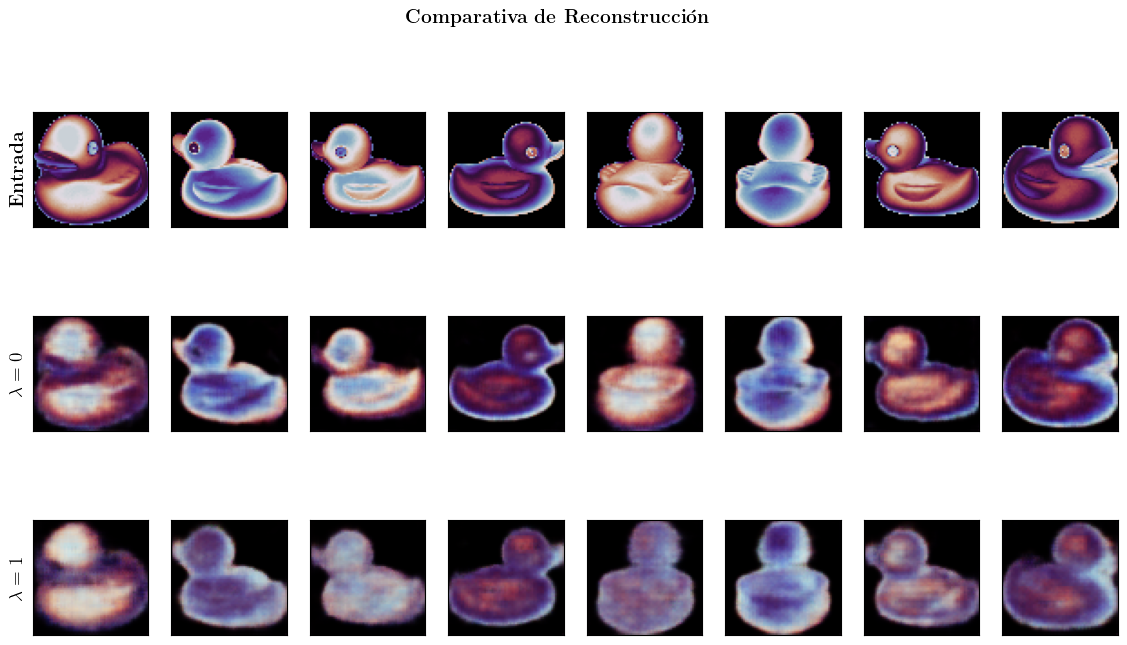

In [ ]:
def plot_reconstructions(models_dict, idx):
    """Compara visualmente las reconstrucciones con fuentes uniformes."""
    n_models = len(models_dict)
    fig, axes = plt.subplots(1 + n_models, len(idx), figsize=(14, 2.5 * (1 + n_models)))

    inp = imgs64[idx]
    for j in range(len(idx)):
        axes[0, j].imshow(inp[j]); axes[0, j].set_xticks([]); axes[0, j].set_yticks([])
    axes[0, 0].set_ylabel(r"\textbf{Entrada}", fontsize=14)

    for row, (label, model) in enumerate(models_dict.items(), start=1):
        model.eval()
        with torch.no_grad():
            rec = model(Xg[idx])[0].cpu().numpy().transpose(0, 2, 3, 1)
        for j in range(len(idx)):
            axes[row, j].imshow(np.clip(rec[j], 0, 1))
            axes[row, j].set_xticks([]); axes[row, j].set_yticks([])
        axes[row, 0].set_ylabel(label, fontsize=14)

    fig.suptitle(r"\textbf{Comparativa de Reconstrucción}", fontsize=14)
    plt.show()

# Verificamos si los modelos existen antes de graficar
if 'model0' in globals() and 'model1' in globals():
    idx = np.random.default_rng(0).choice(n, 8, replace=False)
    plot_reconstructions({r"$\lambda=0$": model0, r"$\lambda=1$": model1}, idx)
else:
    print("Error: Debes ejecutar la celda de entrenamiento (07tj24kcGo9k) primero.")

## 3.5 Comparación del espacio latente


In [ ]:
import plotly.express as px

def plot_latent_plotly(Z, label):
    """Visualiza el espacio latente con fuentes uniformes de 14pt."""
    param_configs = [
        {"vals": theta_rot, "cbar_label": "Ángulo <i>θ</i><sub>rot</sub> (rad)",
         "title_txt": f"Espacio Latente 3D ({label}) — Ángulo de Rotación"},
        {"vals": theta_col, "cbar_label": "Fase <i>φ</i> ∈ [0, 2<i>π</i>)",
         "title_txt": f"Espacio Latente 3D ({label}) — Fase de Color"},
    ]
    for cfg in param_configs:
        figz = px.scatter_3d(
            x=Z[:, 0], y=Z[:, 1], z=Z[:, 2],
            color=cfg["vals"], color_continuous_scale="twilight",
            labels={"color": cfg["cbar_label"]},
            title=f"<b>{cfg['title_txt']}</b>",
        )
        figz.update_traces(marker=dict(size=3, opacity=0.85))
        figz.update_layout(
            width=800, height=650,
            font=dict(family="Computer Modern, serif", size=14),
            title=dict(x=0.5, xanchor="center", font=dict(size=14)),
            scene=dict(
                xaxis=dict(title=dict(text="z1", font=dict(size=14))),
                yaxis=dict(title=dict(text="z2", font=dict(size=14))),
                zaxis=dict(title=dict(text="z3", font=dict(size=14))),
            ),
            margin=dict(l=20, r=20, b=20, t=70),
        )
        figz.show()

# Ejecución segura: solo si el entrenamiento terminó
if 'Z0' in globals() and 'Z1' in globals():
    plot_latent_plotly(Z0, "Control, λ=0")
    plot_latent_plotly(Z1, "Topológico, λ=1")
else:
    print("Error")